<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto Random Forest**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto Random Forest  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Prediciendo la diabetes**

**Objetivo**: En este proyecto el objetivo es mejorar el modelo realizado en el proyecto de arbol de decision para aumentar el accuracy. 
</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **diabetes.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/diabetes.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocesamiento
from sklearn.impute import SimpleImputer
# División de datos
from sklearn.model_selection import train_test_split
# Modelos
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import accuracy_score
# Importamos la librería para guardar modelos
import joblib


In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/diabetes.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
222,7,119,0,0,0,25.2,0.209,37,0
763,10,101,76,48,180,32.9,0.171,63,0
496,5,110,68,0,0,26.0,0.292,30,0
506,0,180,90,26,90,36.5,0.314,35,1
202,0,108,68,20,0,27.3,0.787,32,0
632,2,111,60,0,0,26.2,0.343,23,0
43,9,171,110,24,240,45.4,0.721,54,1
751,1,121,78,39,74,39.0,0.261,28,0
646,1,167,74,17,144,23.4,0.447,33,1
582,12,121,78,17,0,26.5,0.259,62,0


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.1: Limpiar nulos (ceros)**

</div>

In [3]:
# Contar ceros por columna en todo el dataset
ceros = (df == 0).sum()

# Convertir a DataFrame para verlo mejor
ceros_df = ceros.to_frame(name='num_ceros')

# Añadir porcentaje
ceros_df['porcentaje'] = (ceros_df['num_ceros'] / len(df)) * 100

# Ordenar de mayor a menor
ceros_df = ceros_df.sort_values(by='num_ceros', ascending=False)

ceros_df

,num_ceros,porcentaje
Outcome,500,65.104167
Insulin,374,48.697917
SkinThickness,227,29.557292
Pregnancies,111,14.453125
BloodPressure,35,4.557292
BMI,11,1.432292
Glucose,5,0.651042
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000


In [4]:
# Creamos una copia del dataset para trabajar sin modificar el original
df_sinceros = df.copy()

In [5]:
# Reemplazamos los valores 0 por NaN en variables donde no son fisiológicamente posibles
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df_sinceros[col] = df_sinceros[col].replace(0, np.nan)

In [6]:
# Imputamos los valores faltantes utilizando la mediana para evitar sesgos por outliers

imputer = SimpleImputer(strategy='median')
df_sinceros[cols_with_zeros] = imputer.fit_transform(df_sinceros[cols_with_zeros])


In [7]:
# Verificamos el número de ceros en todas las variables tras el tratamiento
ceros_sinceros = (df_sinceros == 0).sum()

ceros_sinceros

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.2: Separar X y y**

</div>

In [8]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df_sinceros.drop(columns='Outcome')
y = df_sinceros['Outcome']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.3: Train / Test split**

</div>

In [9]:
# Dividimos los datos en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


--------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Construye un random forest (modelo base)**

</div>

In [10]:
# Entrenamos el modelo con los valores por defecto a saber: 
# n_estimators = 100
# max_depth = None → crece todo lo que pueda
# min_samples_split = 2
# min_samples_leaf = 1
# max_features = "sqrt" (en clasificación)
# bootstrap = True

model_base = RandomForestClassifier(random_state = 42)

model_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Predecimos y medimos el modelo base**

</div>

In [11]:
# Generamos las predicciones del modelo base sobre el conjunto de test
y_pred_base = model_base.predict(X_test)

In [12]:
# Vemos cuanto es el accuracy de este modelo
acc_base = accuracy_score(y_test, y_pred_base)
acc_base

0.7792207792207793

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

El modelo base de Random Forest alcanza un rendimiento muy similar, pero no supera al obtenido con el árbol de decisión ajustado con `criterion='entropy'`. Esto sugiere que, para este dataset, el uso de un ensemble no supone una mejora clara en términos de accuracy frente a un árbol individual bien configurado.

Aun así, Random Forest sigue siendo una alternativa interesante por su capacidad para generar predicciones más estables y por su menor sensibilidad al sobreajuste en muchos problemas.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Probar con hiperparametros**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota:**

Se modificarán únicamente los hiperparámetros `n_estimators` y `bootstrap`, ya que son los que hacen referencia al funcionamiento del Random Forest como modelo de ensemble. El resto de hiperparámetros se mantendrán con sus valores por defecto.

</div>

In [13]:
# Creamos una lista vacía para almacenar los resultados de cada combinación de hiperparámetros
results = []

# Definimos los valores que queremos probar para cada hiperparámetro
n_estimators_list = [50, 100, 200, 300]   # Número de árboles en el bosque
bootstrap_list = [True, False]            # Uso o no de muestreo con reemplazo

# Iteramos sobre todas las combinaciones posibles de hiperparámetros
for n in n_estimators_list:
    for b in bootstrap_list:

        # Creamos un modelo temporal con la combinación actual
        model_temp = RandomForestClassifier(
            n_estimators=n,
            bootstrap=b,
            random_state=42
        )

        # Entrenamos el modelo con los datos de entrenamiento
        model_temp.fit(X_train, y_train)

        # Generamos predicciones sobre el conjunto de test
        y_pred_temp = model_temp.predict(X_test)

        # Calculamos el accuracy del modelo
        acc = accuracy_score(y_test, y_pred_temp)

        # Guardamos los resultados junto con los hiperparámetros utilizados
        results.append({
            "n_estimators": n,
            "bootstrap": b,
            "accuracy": acc
        })

# Convertimos la lista de resultados en un DataFrame para facilitar su análisis
results_df = pd.DataFrame(results)
results_df

,n_estimators,bootstrap,accuracy
0,50,True,0.746753
1,50,False,0.733766
2,100,True,0.779221
3,100,False,0.740260
4,200,True,0.740260
5,200,False,0.727273
6,300,True,0.733766
7,300,False,0.733766


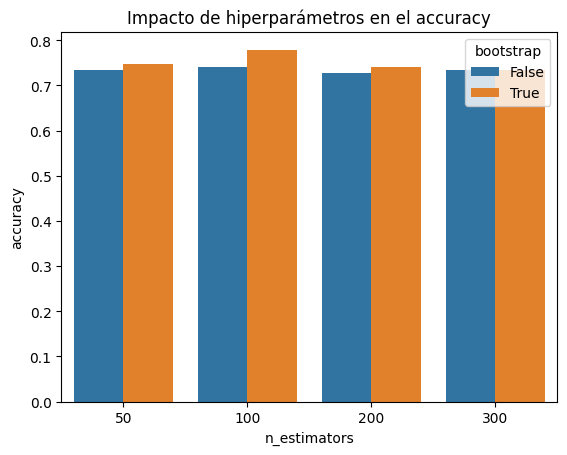

In [14]:
# graficamos los resultados 
sns.barplot(data=results_df, x="n_estimators", y="accuracy", hue="bootstrap")
plt.title("Impacto de hiperparámetros en el accuracy")
plt.show()

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión probar con hiperparametros**

Tras evaluar distintas combinaciones de los hiperparámetros `n_estimators` y `bootstrap`, se observa que el modelo de Random Forest no logra superar al árbol de decisión previamente ajustado con `criterion='entropy'`, obteniendo un rendimiento ligeramente inferior en términos de accuracy.

El aumento del número de árboles no produce mejoras significativas y, en algunos casos, reduce ligeramente el rendimiento. Asimismo, el uso de `bootstrap=True` proporciona resultados más consistentes frente a su desactivación.

Estos resultados indican que, para este conjunto de datos, el modelo base de Random Forest ya se encuentra en una configuración adecuada, pero no aporta una mejora clara frente a un modelo más simple, lo que refuerza la idea de que una mayor complejidad no siempre implica un mejor rendimiento.

</div>

_____________

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Guardar el modelo**

</div>

In [15]:
# Guardamos el modelo optimizado
joblib.dump(model_base, '../models/random_forest_diabetes.sav')

['../models/random_forest_diabetes.sav']

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final del proyecto**

En este proyecto se ha comparado el rendimiento de un modelo de árbol de decisión con un modelo Random Forest aplicado al mismo conjunto de datos.

El modelo Random Forest ha demostrado ofrecer un rendimiento más estable al combinar múltiples árboles de decisión, reduciendo el riesgo de sobreajuste asociado a modelos individuales. Sin embargo, tras analizar distintas combinaciones de hiperparámetros (`n_estimators` y `bootstrap`), se observa que el modelo base ya presentaba el mejor rendimiento en términos de accuracy.

El aumento del número de árboles no ha supuesto una mejora significativa y, en algunos casos, ha reducido ligeramente el rendimiento. Esto sugiere que, para este dataset, el modelo ya se encontraba en una configuración adecuada y que una mayor complejidad no siempre se traduce en mejores resultados.

En conclusión, este análisis refuerza la importancia de evaluar modelos en función del problema y los datos disponibles, en lugar de asumir que modelos más complejos ofrecerán siempre mejores resultados.

</div>